# Simulation KNN essentielle

Changez seulement `k_user` puis relancez la cellule de code.

Repères rapides :
- KNN regarde les voisins les plus proches puis vote.
- `k_user` est le nombre de voisins utilisés.
- Le cercle pointillé montre la zone de recherche.
- Les points entourés en turquoise sont les voisins pris en compte.
- Le `?` est le nouveau point à classifier.

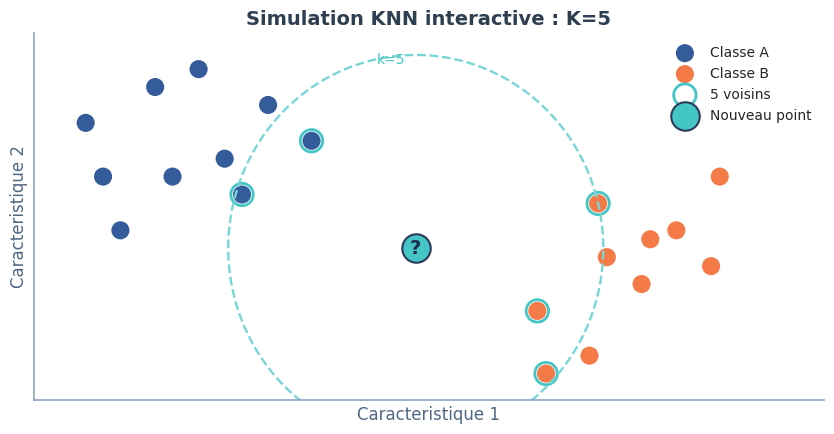

Classe predite: Classe B


In [ ]:
import numpy as np  # Bibliothèque pour manipuler les tableaux numériques
import matplotlib.pyplot as plt  # Bibliothèque pour tracer le graphique
from sklearn.neighbors import KNeighborsClassifier  # Modèle KNN de scikit-learn

# 1) Paramètre à modifier
k_user = 5  # Essayez 1, 3, 5, 7, 9

# 2) Données de démonstration : classe A (bleu) et classe B (orange)
classe_a_i = np.array([
    [1.0, 4.2], [1.4, 3.0], [2.0, 3.6], [2.3, 4.8], [2.8, 3.4],
    [3.1, 4.4], [1.8, 4.6], [2.6, 3.8], [3.6, 4.0], [1.2, 3.6]
])
classe_b_i = np.array([
    [6.2, 2.1], [6.8, 1.6], [7.4, 2.4], [7.8, 3.0], [8.2, 2.6],
    [6.9, 3.3], [7.5, 2.9], [8.3, 3.6], [6.3, 1.4], [7.0, 2.7]
])

# Construire le jeu de données complet
X_i = np.vstack([classe_a_i, classe_b_i])
y_i = np.array([0] * len(classe_a_i) + [1] * len(classe_b_i))

# Nouveau point à classifier
new_point_i = np.array([[4.8, 2.8]])

# Sécuriser k pour éviter les erreurs
k_user = int(max(1, min(k_user, len(X_i))))

# 3) Entraînement et prédiction
knn_i = KNeighborsClassifier(n_neighbors=k_user)
knn_i.fit(X_i, y_i)
pred_i = knn_i.predict(new_point_i)[0]

# Récupérer les k voisins les plus proches
dist_i, idx_i = knn_i.kneighbors(new_point_i, n_neighbors=k_user)

# Le rayon du cercle = distance du voisin le plus éloigné parmi les k voisins
rayon_i = dist_i[0][-1]

# Coordonnées des voisins à entourer
voisins_i = X_i[idx_i[0]]

# 4) Visualisation
plt.figure(figsize=(8.5, 4.5))
ax = plt.gca()

# Tracer les deux classes
plt.scatter(classe_a_i[:, 0], classe_a_i[:, 1], s=170, c="#355C9A", edgecolors="none", label="Classe A")
plt.scatter(classe_b_i[:, 0], classe_b_i[:, 1], s=170, c="#F47A48", edgecolors="none", label="Classe B")

# Entourer les voisins qui participent au vote
plt.scatter(voisins_i[:, 0], voisins_i[:, 1], s=260, facecolors="none", edgecolors="#44C6C6", linewidth=2.0, label=f"{k_user} voisins")

# Tracer le nouveau point
plt.scatter(new_point_i[:, 0], new_point_i[:, 1], s=420, c="#44C6C6", edgecolors="#2E3A59", linewidth=1.5, label="Nouveau point", zorder=5)
plt.text(new_point_i[0, 0], new_point_i[0, 1], "?", ha="center", va="center", fontsize=14, color="#1C2C4A", weight="bold", zorder=6)

# Tracer le cercle pointillé de recherche
circle_i = plt.Circle((new_point_i[0, 0], new_point_i[0, 1]), rayon_i, fill=False, linestyle="--", linewidth=1.7, color="#79D6D6")
ax.add_patch(circle_i)
plt.text(new_point_i[0, 0] - 0.45, new_point_i[0, 1] + rayon_i - 0.1, f"k={k_user}", color="#44C6C6", fontsize=10)

# Habillage du graphique
plt.title(f"Simulation KNN interactive : K={k_user}", fontsize=14, weight="bold", color="#2F3F52")
plt.xlabel("Caracteristique 1", color="#506784")
plt.ylabel("Caracteristique 2", color="#506784")
plt.xlim(0.4, 9.5)
plt.ylim(1.1, 5.2)
plt.xticks([])
plt.yticks([])

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#8CA3C0")
ax.spines["bottom"].set_color("#8CA3C0")
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

plt.legend(loc="upper right", frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

# 5) Résultat final
print("Classe predite:", "Classe A" if pred_i == 0 else "Classe B")